# Micrograd - Autograd engine

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [94]:
# Graphviz boilerplate code
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

## Understand derivatives

In [3]:
def f(x):
  return 3*x**2 - 4*x + 5

In [4]:
f(3.0)

20.0

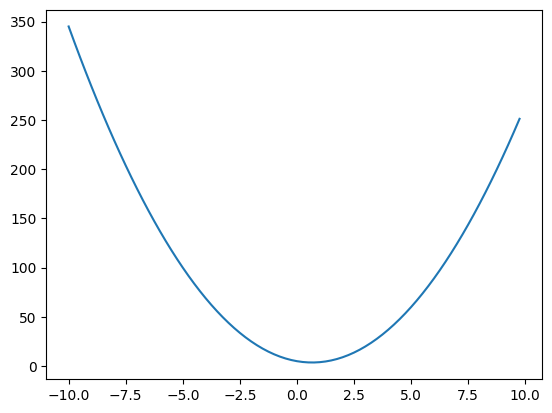

In [7]:
xs = np.arange(-10, 10, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [ ]:
# We will try to calculate the derivate of the function wrt to the input -- numerically.
h = 0.000001
x = 3
(f(x + h) - f(x))/h

# If we do df/dx for the function above we get: 6x-4
# So when we plug in x=3 -- That would be 14. Which matches the value for the expression because we are using the limits formula
# for the numerical derivative. Which is basically telling us the slope when we make that small change in the positive direction
# at the x=3 point in this graph/expression.

14.000003002223593

In [9]:
# let's get more complex
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [15]:
# Numerical derivative
h = 0.00001

# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)

# The slope is -3 because that's what you would get if you do d2/da. Similarly we can derive for d2/db, d2/dc.

d1 4.0
d2 3.9999699999999994
slope -3.000000000064062


## Start building the Value class

This is the main part that allows us to emulate what autograd in pytorch does.

In [103]:
class Value:
    
    # Children allow us to track which nodes produced other nodes.
    def __init__(self, data, _prev = (), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_prev)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        return Value(self.data + other.data, (self, other), '+')
    
    def __mul__(self, other):
        return Value(self.data * other.data, (self, other), '*')
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')
        return out

In [79]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L=d*f; L.label='L'

print(d)
print(d._prev)
print(d._op)
L

Value(data=4.0)
{Value(data=10), Value(data=-6.0)}
+


Value(data=-8.0)

In [92]:
# Derivatives from calculus.
# dL/dL = 1
L.grad = 1.0

# dL/df = d and dL/dd = f
d.grad = -2.0
f.grad = 4.0

# Now derive dL/dc. We have computed all the other nodes, as we have to do backprop in the reverse direction.
# d = e + c
# dd/dc = 1.0
# dL/dc = dL/dd * dd/dc
c.grad = -2.0

# dd/de = 1.0
# dL/de = dL/dd * dd/de
e.grad = -2.0

# e = a * b
# de/da = b
# dL/da = dL/de * de/da
a.grad = -2.0 * -3.0            # 6.0

# de/db = a
b.grad = -2.0 * 2.0


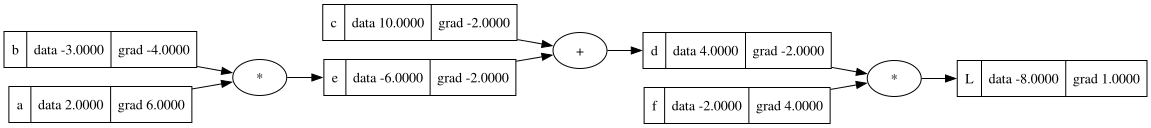

In [95]:
# Here we are visualizing the forward pass and the gradients from the backward pass.
draw_dot(L)

In [99]:
# We can just use this function to check the derivatives numerically by adding h to any of the variables that we want to check the gradients for.
# It's an inline gradient check.

# Uncomment the respective `+=h` line to check the grad computation for that node.
# It tells you the effect of changing that value on the output of the expression. In this case that's L.
def lol():
  
  h = 0.001
  
  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0, label='f')
  L = d * f; L.label = 'L'
  L1 = L.data
  
  a = Value(2.0, label='a')
  a.data += h
  b = Value(-3.0, label='b')
  # b.data += h
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  # d.data += h
  f = Value(-2.0, label='f')
  # f.data += h
  L = d * f; L.label = 'L'
  L2 = L.data
  
  print((L2 - L1)/h)
  
lol()

6.000000000000227


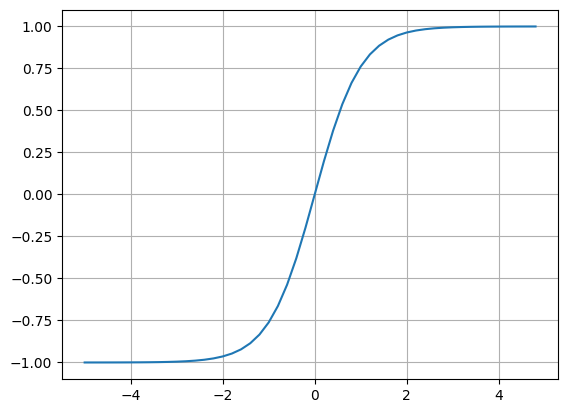

In [100]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid();

In [108]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'

n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh(); o.label = 'o'

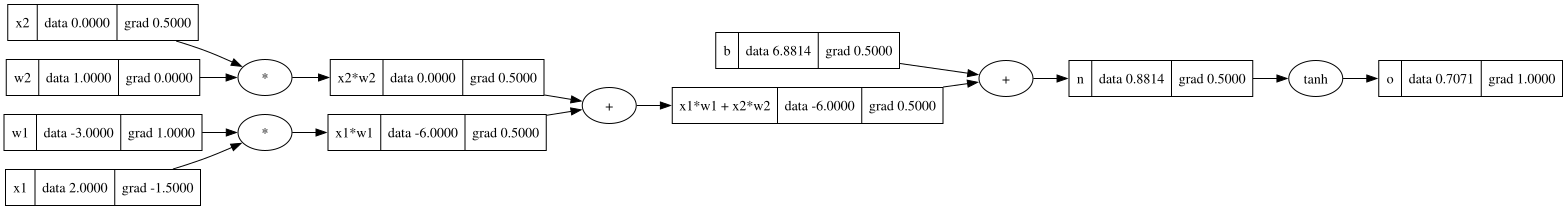

In [119]:
draw_dot(o)

In [ ]:
# Now we will manually compute the grad for each of the nodes in the graph above (similar to how we did it for the earlier equation).
o.grad = 1.0

# o = tanh(n)
# do/dn = 1 - tanh(n) ** 2 = 1 - o.data**2
n.grad = 1 - o.data**2

# Going further back we have an addition. For addition as we know, the gradient should just flow as per the chain rule
# because the local derivative would be 1.0
b.grad = n.grad
x1w1x2w2.grad = n.grad

# More plus going back so the gradient keeps flowing
x1w1.grad = n.grad
x2w2.grad = n.grad

# Now we have mul at the leftmost end
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad